In [1]:
import os
import subprocess
import scanpy as sc
import anndata as ad
import pandas as pd

In [4]:
url="ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE194nnn/GSE194122/suppl/GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz"
filename="GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz"

unzipped_filename = "../data/" + filename.replace(".gz", "")
if not os.path.isfile(unzipped_filename):
    raise ValueError("must download data and put in folder")

def download_bone_marrow_data(
    url="ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE194nnn/GSE194122/suppl/GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz",
    filename="GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz",
) -> ad.AnnData:
    """
    Downloads, unzips, and loads the bone marrow dataset.
    """
    unzipped_filename = filename.replace(".gz", "")
    if not os.path.isfile(unzipped_filename):
        if not os.path.isfile(filename):
            subprocess.run(["wget", url, "--no-verbose"])
        subprocess.run(["gunzip", filename])

    return sc.read_h5ad(unzipped_filename)

adata_raw = sc.read_h5ad(unzipped_filename)

/Users/tlong/Documents/code/uPHATE/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [5]:
def preprocess_adata(
    adata: ad.AnnData,
    min_genes: int = 100,
    min_cells: int = 3,
    n_top_genes: int = 2000,
    n_pcs: int = 50,
    batch_key: str = "Samplename",
    run_scrublet: bool = False,
) -> ad.AnnData:
    """
    Runs the full scRNA-seq preprocessing pipeline on an AnnData object.

    Args:
        adata (ad.AnnData): The raw AnnData object.
        min_genes (int): Min genes for cell filtering.
        min_cells (int): Min cells for gene filtering.
        n_top_genes (int): Number of highly variable genes to select.
        n_pcs (int): Number of principal components to compute.
        batch_key (str): The key in .obs for batch correction (if any).
        run_scrublet (bool): Whether to run doublet detection.

    Returns:
        ad.AnnData: The processed AnnData object.
    """
    print("--- Starting Preprocessing ---")

    # 1. Initial setup and QC gene flagging
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

    # 2. Calculate QC
    sc.pp.calculate_qc_metrics(
        adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
    )

    # 3. Remove QC genes
    genes_to_remove = adata.var["mt"] | adata.var["ribo"]
    adata._inplace_subset_var(~genes_to_remove)

    # 4. Filter cells, genes, and detect doublets
    sc.pp.filter_cells(adata, min_genes=min_genes)
    sc.pp.filter_genes(adata, min_cells=min_cells)
    if run_scrublet:
        sc.pp.scrublet(adata, batch_key=batch_key)

    # 5. Normalize and find HVGs
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, batch_key=batch_key)

    # 6. Run PCA
    sc.tl.pca(adata, n_comps=n_pcs, use_highly_variable=True)

    return adata

In [6]:
def prepare_data(
    groupby_key: str = "cell_type", n_pcs: int = 50, batch_key: str = "Samplename"
) -> ad.AnnData:
    """
    Loads, concatenates, and preprocesses the scRNA-seq data.
    """
    adata_raw.var_names_make_unique()

    # Slice and concatenate data
    if groupby_key == "cell_type":
        adata_subset1 = adata_raw[
            adata_raw.obs["Samplename"] == "site1_donor1_cite", :
        ].copy()
        adata_subset3 = adata_raw[
            adata_raw.obs["Samplename"] == "site1_donor3_cite", :
        ].copy()
        adata_filtered = ad.concat([adata_subset1, adata_subset3], label="donors")
    else:
        adata_filtered = adata_raw

    adata_filtered.obs_names_make_unique()

    # Run the preprocessing pipeline on ALL concatenated cells first
    adata_processed = preprocess_adata(
        adata_filtered,  # <-- Use the unfiltered data
        n_top_genes=2000,
        n_pcs=n_pcs,
        batch_key=batch_key,
    )

    # Now, filter to the top cell types for your analysis

    if groupby_key == "cell_type":
        top_cell_types = (
            adata_processed.obs[groupby_key].value_counts().nlargest(12).index
        )
        # This subset now contains the .obsm['X_pca'] that was calculated on ALL cells
        adata_final = adata_processed[
            adata_processed.obs[groupby_key].isin(top_cell_types)
        ].copy()
    if groupby_key.lower() == "cd4+_t_cell_type":
        adata_subset1 = adata_processed[
            adata_processed.obs["cell_type"] == "CD4+ T activated", :
        ].copy()
        adata_subset3 = adata_processed[
            adata_processed.obs["cell_type"] == "CD4+ T naive", :
        ].copy()

        adata_t_cells = ad.concat([adata_subset1, adata_subset3], label="T_cell_type")

        adata_final = sc.preprocess_adata(
            adata_t_cells,
            n_top_genes=1000,  # You can use fewer HVGs for a subset
            n_pcs=50,  # You need fewer PCs for a subset
            batch_key="Samplename",
        )

    return adata_final


N_PCS = 50
GROUPBY_KEY = "cell_type"
MODEL_PATH_PATTERN = "models/umap_{i}.pth"
SUMMARY_BASENAME = "saved_outputs/bmmc_features_rev"
BATCH_KEY = "Samplename"

adata_final = prepare_data(groupby_key=GROUPBY_KEY, n_pcs=N_PCS, batch_key=BATCH_KEY)

--- Starting Preprocessing ---


/Users/tlong/Documents/code/uPHATE/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


In [7]:
import jax
import jax.numpy as jnp
from uphate import get_phate_embedding

In [8]:
indices = jax.random.choice(
    jax.random.key(41),
    a=adata_final.shape[0],
    shape=(1000,),
    replace=False,
)
X = jnp.array(adata_final.obsm["X_pca"][indices])
Y = jax.jit(
    get_phate_embedding, static_argnames=["t", "n_components", "knn", "decay", "gamma"]
)(X, key=jax.random.key(42), t=5, knn=25).block_until_ready()

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

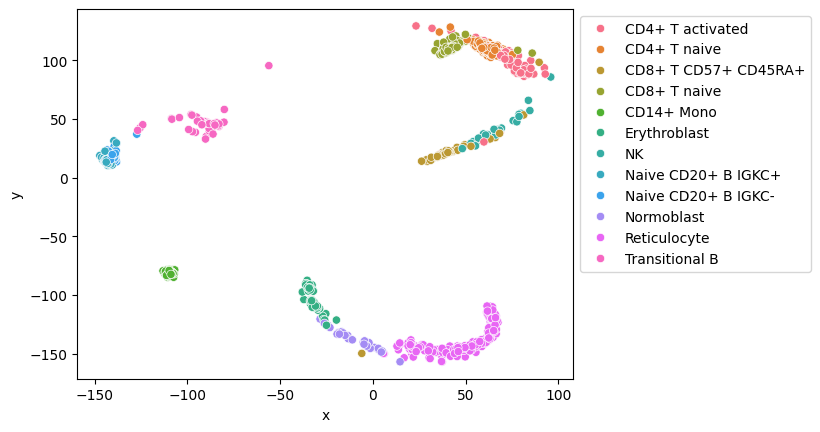

In [10]:
fig, ax = plt.subplots()

df = pd.DataFrame(Y, columns=["x", "y"]) 
df["cell_type"] = adata_final.obs["cell_type"].values[indices]
sns.scatterplot(df, x="x", y="y", hue="cell_type", ax=ax)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

In [12]:
from uphate.uphate import (
    compute_affinity_matrix,
    compute_diff_op,
    compute_diffusion_potential,
    compute_classic_mds_embedding,
    compute_metric_mds_embedding,
    pdist_squared,
)

t: float = 5
n_components: int = 2
knn: float = 25
decay: float = 40.0
n_landmark = None
gamma: float = 1.0

affinity_matrix = compute_affinity_matrix(
    X,
    n_landmark=n_landmark,
    knn=knn,
    decay=decay,
)
diff_op = compute_diff_op(affinity_matrix)
diff_potential = compute_diffusion_potential(diff_op, t, gamma)
init_embedding = compute_classic_mds_embedding(
    pdist_squared(diff_potential), n_components=n_components
)

In [44]:
weights = jax.random.dirichlet(jax.random.key(41), alpha=jnp.ones(X.shape[0]))
weighted_affinity_matrix = (affinity_matrix * weights[None, :])
weighted_diff_op = weighted_affinity_matrix / weighted_affinity_matrix.sum(axis=1, keepdims=True)